In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, gll
from ariel_pred.sigma import OGSignalVarBasedSigmaCalculator
from ariel_pred.modeling.s_values_cnn_with_star_info import SValuesCNNWithStarInfoModel, SValuesCNNWithStarInfoTrainer
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn
import scipy

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [4]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
    wavelengths_groups=[1, 2, 4, 8, 16, 32, 64],
    weights=[1, 1, 1, 1, 1, 1, 1]
)

features.shape

  0%|          | 0/1100 [00:00<?, ?it/s]

(1100, 283, 7)

In [5]:
spectrum = np.load("../models/s_values_cnn_with_star_info_res/s_values_cnn_with_star_info_val_preds.npy")
spectrum.shape

(1100, 283)

In [6]:
sigma_calculator = OGSignalVarBasedSigmaCalculator(
    mean_fgs_sigma = 9.0e-4,
    mean_airs_sigma = 6.0e-4,
    fgs_min_sigma = 1e-6,
    airs_min_sigma = 1e-6,
)
sigma = sigma_calculator.get_sigma(train_data)
gll(np.concatenate([spectrum, sigma], axis=1), train_labels)

  0%|          | 0/1100 [00:00<?, ?it/s]

Calculating FGS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

Calculating AIRS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

0.394389894866441

In [9]:
def cost_function(params, x, mu):
    sigma = params[0]
    return (0.5 * (np.log(2 * np.pi) + np.log(sigma**2) + ((x - mu)**2) / (sigma**2))).mean()

optimal_sigma = np.zeros(spectrum.shape[0])

for i in tqdm(range(spectrum.shape[0])):
    res = minimize(cost_function, [0.00068], args=(train_labels[i], spectrum[i]), bounds=[(1e-6, 0.01)])
    optimal_sigma[i] = res.x[0]

  0%|          | 0/1100 [00:00<?, ?it/s]

In [11]:
optimal_sigma.mean()

np.float64(0.0003343508051544436)

In [12]:
gll(np.concatenate([spectrum, np.repeat(optimal_sigma[:, np.newaxis], spectrum.shape[1], axis=1)], axis=1), train_labels)

0.47930224643569885

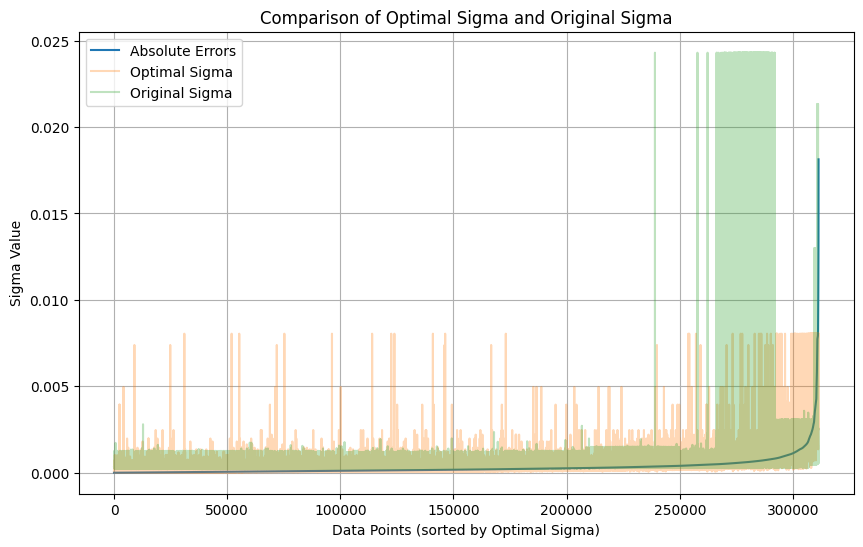

In [18]:
flat_optimal_sigma = np.repeat(optimal_sigma[:, np.newaxis], spectrum.shape[1], axis=1).flatten()
flat_sigma = sigma.flatten()
flat_errors = np.abs(spectrum - train_labels).flatten()

plt.figure(figsize=(10, 6))
plt.plot(np.sort(flat_errors), label='Absolute Errors')
plt.plot(flat_optimal_sigma[np.argsort(flat_errors)], label='Optimal Sigma', alpha=0.3)
plt.plot(flat_sigma[np.argsort(flat_errors)], label='Original Sigma', alpha=0.3)
plt.xlabel('Data Points (sorted by Optimal Sigma)')
plt.ylabel('Sigma Value')
plt.title('Comparison of Optimal Sigma and Original Sigma')
plt.legend()
plt.grid()
plt.show()

In [19]:
def airs_cost_function(params, x, mu):
    sigma = params[0]
    return (0.5 * (np.log(2 * np.pi) + np.log(sigma**2) + ((x - mu)**2) / (sigma**2))).mean()

optimal_airs_sigma = np.zeros(spectrum.shape[0])

for i in tqdm(range(spectrum.shape[0])):
    res = minimize(airs_cost_function, [0.00068], args=(train_labels[i, 1:], spectrum[i, 1:]), bounds=[(1e-6, 0.01)])
    optimal_airs_sigma[i] = res.x[0]
    
def fgs_cost_function(params, x, mu):
    sigma = params[0]
    return (0.5 * (np.log(2 * np.pi) + np.log(sigma**2) + ((x - mu)**2) / (sigma**2))).mean()

optimal_fgs_sigma = np.zeros(spectrum.shape[0])

for i in tqdm(range(spectrum.shape[0])):
    res = minimize(fgs_cost_function, [0.00068], args=(train_labels[i, 0], spectrum[i, 0]), bounds=[(1e-6, 0.01)])
    optimal_fgs_sigma[i] = res.x[0]


  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

In [20]:
optimal_airs_sigma.mean(), optimal_fgs_sigma.mean()

(np.float64(0.00033314831422950956), np.float64(0.0004384822091786151))

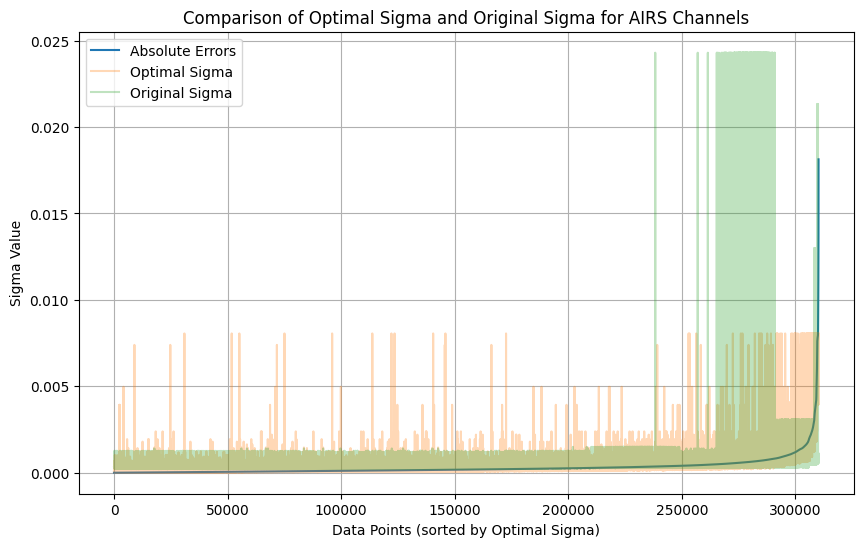

In [21]:
airs_flat_optimal_sigma = np.repeat(optimal_airs_sigma[:, np.newaxis], 282, axis=1).flatten()
airs_flat_sigma = sigma[:, 1:].flatten()
airs_flat_errors = np.abs(spectrum[:, 1:] - train_labels[:, 1:]).flatten()

plt.figure(figsize=(10, 6))
plt.plot(np.sort(airs_flat_errors), label='Absolute Errors')
plt.plot(airs_flat_optimal_sigma[np.argsort(airs_flat_errors)], label='Optimal Sigma', alpha=0.3)
plt.plot(airs_flat_sigma[np.argsort(airs_flat_errors)], label='Original Sigma', alpha=0.3)
plt.xlabel('Data Points (sorted by Optimal Sigma)')
plt.ylabel('Sigma Value')
plt.title('Comparison of Optimal Sigma and Original Sigma for AIRS Channels')
plt.legend()
plt.grid()
plt.show()

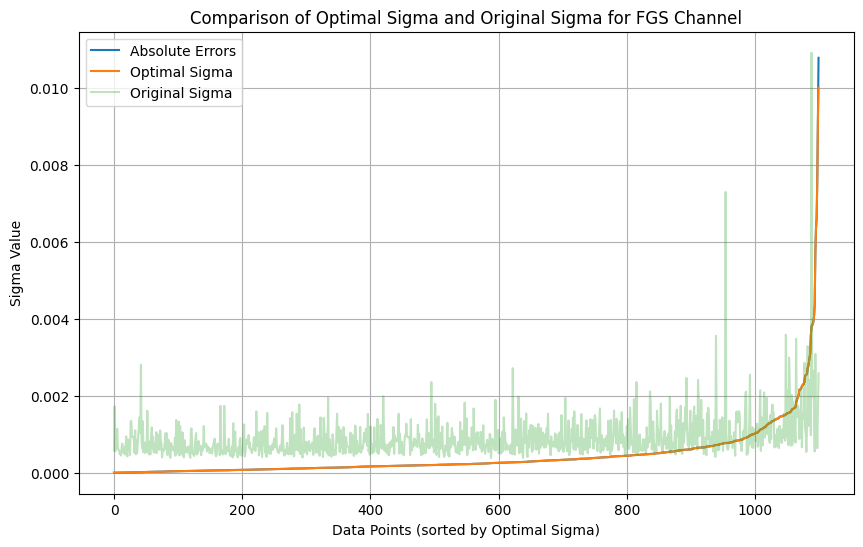

In [24]:
fgs_flat_optimal_sigma = np.repeat(optimal_fgs_sigma[:, np.newaxis], 1, axis=1).flatten()
fgs_flat_sigma = sigma[:, 0].flatten()
fgs_flat_errors = np.abs(spectrum[:, 0] - train_labels[:, 0]).flatten()
plt.figure(figsize=(10, 6))
plt.plot(np.sort(fgs_flat_errors), label='Absolute Errors')
plt.plot(fgs_flat_optimal_sigma[np.argsort(fgs_flat_errors)], label='Optimal Sigma', alpha=1)
plt.plot(fgs_flat_sigma[np.argsort(fgs_flat_errors)], label='Original Sigma', alpha=0.3)
plt.xlabel('Data Points (sorted by Optimal Sigma)')
plt.ylabel('Sigma Value')
plt.title('Comparison of Optimal Sigma and Original Sigma for FGS Channel')
plt.legend()
plt.grid()
plt.show()

In [30]:
gll(np.concatenate([spectrum, np.concatenate([optimal_fgs_sigma[:, np.newaxis], np.repeat(optimal_airs_sigma[:, np.newaxis], 282, axis=1)], axis=1)], axis=1), train_labels)

0.5026004779498219

In [29]:
np.repeat(optimal_airs_sigma[:, np.newaxis], 282, axis=1).shape, optimal_fgs_sigma[:, np.newaxis].shape

((1100, 282), (1100, 1))

In [31]:
gll(np.concatenate([spectrum, np.concatenate([sigma[:, 0][:, np.newaxis], np.repeat(optimal_airs_sigma[:, np.newaxis], 282, axis=1)], axis=1)], axis=1), train_labels)

0.48128551605736203